# CIC-IDS 2017 Data Preprocessing, Feature Engineering & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
from sklearn.preprocessing import StandardScaler, LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Load Raw Data

In [2]:
RAW_DATA_PATH = 'data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv'
df = pd.read_csv(RAW_DATA_PATH, encoding='cp1252', low_memory=False)
df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.replace('\x96', '-').str.strip()

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}):')
print(list(df.columns))
print(f'\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nData types:\n{df.dtypes.value_counts()}')
print(f'\nMissing values per column:\n{df.isna().sum().sort_values(ascending=False).head(20)}')

Shape: (458968, 85)
Columns (85):
['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Fl

## 2. Data Cleaning

In [3]:
# Drop rows that are entirely NaN
df = df.dropna(how='all').reset_index(drop=True)
print(f'After dropping all-NaN rows: {df.shape}')

# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print(f'After dropping duplicates: {df.shape}')

# Check remaining missing values
missing = df.isna().sum()
print(f'Total missing values: {missing.sum()}')
print(f'Columns with missing values:\n{missing[missing > 0]}')

After dropping all-NaN rows: (170366, 85)


After dropping duplicates: (170365, 85)
Total missing values: 20
Columns with missing values:
Flow Bytes/s    20
dtype: int64


In [4]:
METADATA_COLS = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=METADATA_COLS)
print(f'Shape after dropping metadata: {df.shape}')
print(f'Remaining columns: {list(df.columns)}')

Shape after dropping metadata: (170365, 81)
Remaining columns: ['Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count

In [5]:
LABEL_COL = 'Label'
numeric_cols = df.columns[df.columns != LABEL_COL]

# Convert all feature columns to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Replace inf/-inf with NaN
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

df[numeric_cols] = df[numeric_cols].where(df[numeric_cols] >= 0)

print(f'NaNs after coercion and invalid handling: {df[numeric_cols].isna().sum().sum()}')

NaNs after coercion and invalid handling: 184870


In [6]:
for col in numeric_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f'NaNs after median imputation: {df[numeric_cols].isna().sum().sum()}')

NaNs after median imputation: 0


## 3. Label Encoding

In [7]:
df['Label_binary'] = np.where(df[LABEL_COL] == 'BENIGN', 'BENIGN', 'ATTACK')
df['Label_encoded'] = (df['Label_binary'] == 'ATTACK').astype(int)

le = LabelEncoder()
df['Label_multiclass'] = le.fit_transform(df[LABEL_COL])

print('Multiclass label distribution:')
print(df[LABEL_COL].value_counts())
print('\nBinary label distribution:')
print(df['Label_binary'].value_counts())
print(f'\nEncoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Multiclass label distribution:
Label
BENIGN                        168185
Web Attack – Brute Force        1507
Web Attack – XSS                 652
Web Attack – Sql Injection        21
Name: count, dtype: int64

Binary label distribution:
Label_binary
BENIGN    168185
ATTACK      2180
Name: count, dtype: int64

Encoded classes: {'BENIGN': 0, 'Web Attack – Brute Force': 1, 'Web Attack – Sql Injection': 2, 'Web Attack – XSS': 3}


## 4. Feature Engineering

In [8]:
# Flag-based features
df['total_flags'] = df['FIN Flag Count'] + df['SYN Flag Count'] + df['RST Flag Count'] + df['PSH Flag Count'] + df['ACK Flag Count'] + df['URG Flag Count']
df['syn_ratio'] = df['SYN Flag Count'] / (df['total_flags'] + 1)
df['fin_ratio'] = df['FIN Flag Count'] / (df['total_flags'] + 1)

# Packet size features
df['pkt_len_var_to_mean'] = df['Packet Length Variance'] / (df['Packet Length Mean'] + 1)
df['avg_pkt_size_from_fwd_bwd'] = (df['Avg Fwd Segment Size'] + df['Avg Bwd Segment Size']) / 2

# Flow size features
df['fwd_to_bwd_pkt_ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1)
df['fwd_to_bwd_byte_ratio'] = df['Total Length of Fwd Packets'] / (df['Total Length of Bwd Packets'] + 1)

# IAT features
df['fwd_iat_mean_to_max'] = df['Fwd IAT Mean'] / (df['Fwd IAT Max'] + 1)
df['flow_iat_std_to_mean'] = df['Flow IAT Std'] / (df['Flow IAT Mean'] + 1)

# Subflow features
df['subflow_pkt_ratio'] = df['Subflow Fwd Packets'] / (df['Subflow Bwd Packets'] + 1)

# Active/Idle features
df['active_to_idle_ratio'] = df['Active Mean'] / (df['Idle Mean'] + 1)
df['active_std_to_mean'] = df['Active Std'] / (df['Active Mean'] + 1)

# Flag presence
df['has_syn'] = (df['SYN Flag Count'] > 0).astype(int)
df['has_rst'] = (df['RST Flag Count'] > 0).astype(int)
df['has_fin'] = (df['FIN Flag Count'] > 0).astype(int)


# Additional Feature Engineering
df['fwd_packet_length_range'] = df['Fwd Packet Length Max'] - df['Fwd Packet Length Min']
df['bwd_packet_length_range'] = df['Bwd Packet Length Max'] - df['Bwd Packet Length Min']
df['flow_duration_log'] = np.log1p(df['Flow Duration'])
df['total_fwd_bytes_log'] = np.log1p(df['Total Length of Fwd Packets'])
df['total_bwd_bytes_log'] = np.log1p(df['Total Length of Bwd Packets'])
df['byte_to_packet_ratio'] = df['Flow Bytes/s'] / (df['Flow Packets/s'] + 1)
df['fwd_header_to_pkt_ratio'] = df['Fwd Header Length'] / (df['Total Fwd Packets'] + 1)
df['bwd_header_to_pkt_ratio'] = df['Bwd Header Length'] / (df['Total Backward Packets'] + 1)
# New feature count
new_feat_cols = [c for c in df.columns if c not in [LABEL_COL, 'Label_binary', 'Label_encoded', 'Label_multiclass']]
print(f'Total features after engineering: {len(new_feat_cols)}')
print(f'New features: {[c for c in df.columns if c.startswith(("syn_", "fin_", "pkt_", "fwd_", "flow_", "sub_", "active_", "total_", "has_"))]}')

Total features after engineering: 103
New features: ['total_flags', 'syn_ratio', 'fin_ratio', 'pkt_len_var_to_mean', 'fwd_to_bwd_pkt_ratio', 'fwd_to_bwd_byte_ratio', 'fwd_iat_mean_to_max', 'flow_iat_std_to_mean', 'active_to_idle_ratio', 'active_std_to_mean', 'has_syn', 'has_rst', 'has_fin', 'fwd_packet_length_range', 'flow_duration_log', 'total_fwd_bytes_log', 'total_bwd_bytes_log', 'fwd_header_to_pkt_ratio']


/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_10161/1890106789.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_fwd_bytes_log'] = np.log1p(df['Total Length of Fwd Packets'])
/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_10161/1890106789.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['total_bwd_bytes_log'] = np.log1p(df['Total Length of Bwd Packets'])
/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_10161/1890106789.py:37: PerformanceWarning: DataFrame is highly fragmente

## 5. Visualizations

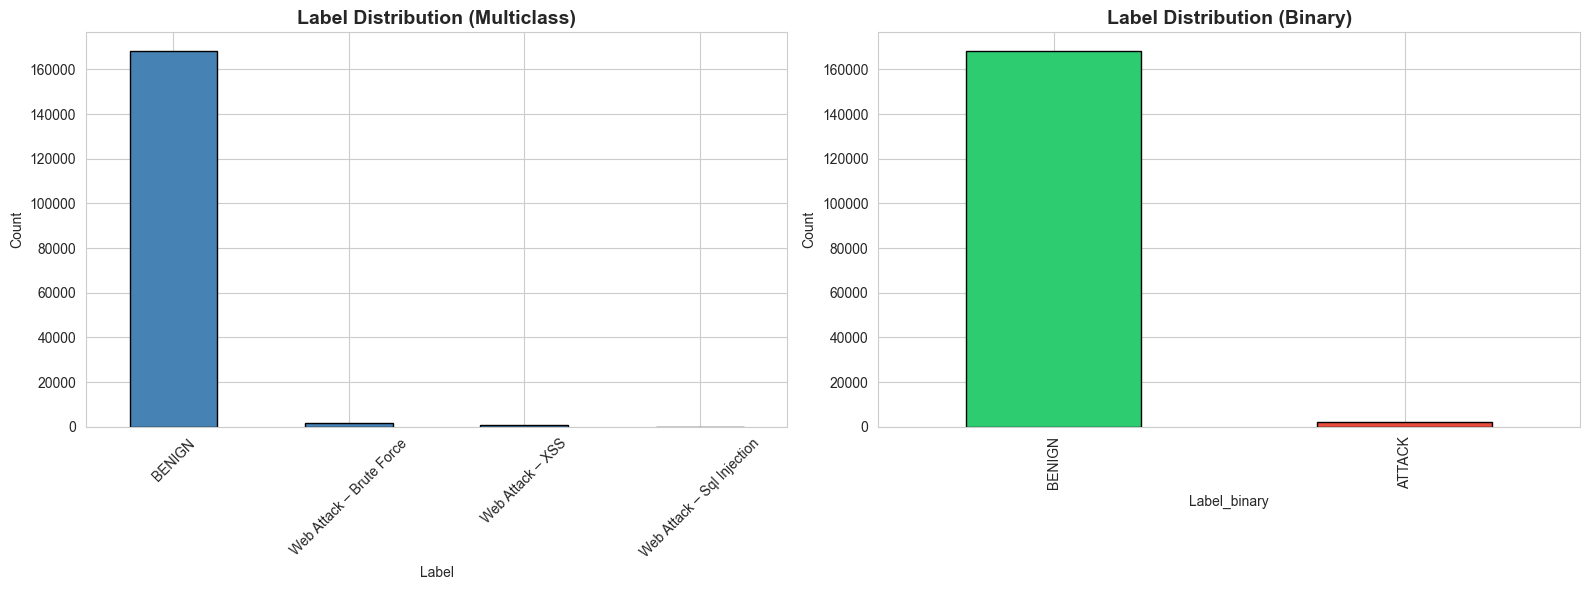

Saved: results/label_distribution.png


In [9]:
# Label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Multiclass
df[LABEL_COL].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Label Distribution (Multiclass)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Binary
df['Label_binary'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Label Distribution (Binary)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/label_distribution.png')

/var/folders/tt/k1lq5c5x7tl4g5pfxq2nx2bw0000gn/T/ipykernel_10161/1697823124.py:12: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=attack_df, x=feat, ax=ax, label='ATTACK', color='red', fill=True, alpha=0.3)


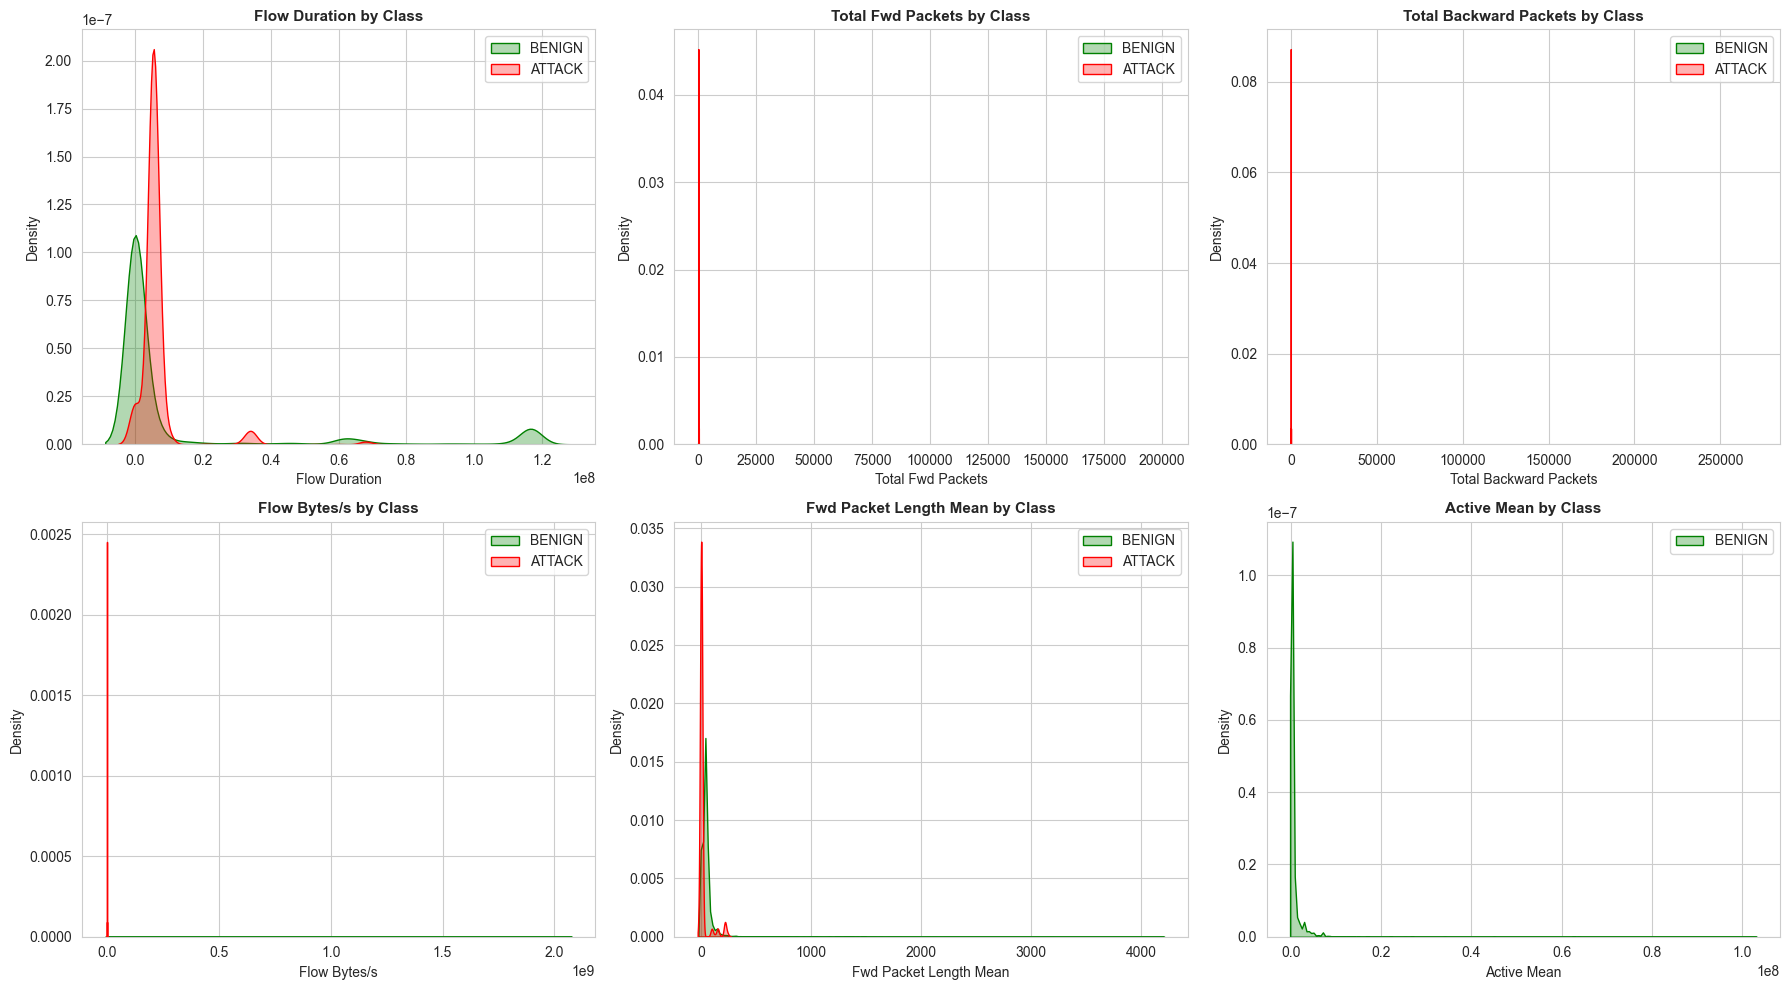

Saved: results/feature_distributions.png


In [10]:
# Distribution of key features by attack type
attack_df = df[df[LABEL_COL] != 'BENIGN']
benign_df = df[df[LABEL_COL] == 'BENIGN']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_to_plot = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                    'Flow Bytes/s', 'Fwd Packet Length Mean', 'Active Mean']

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    sns.kdeplot(data=benign_df, x=feat, ax=ax, label='BENIGN', color='green', fill=True, alpha=0.3)
    sns.kdeplot(data=attack_df, x=feat, ax=ax, label='ATTACK', color='red', fill=True, alpha=0.3)
    ax.set_title(f'{feat} by Class', fontsize=11, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/feature_distributions.png')

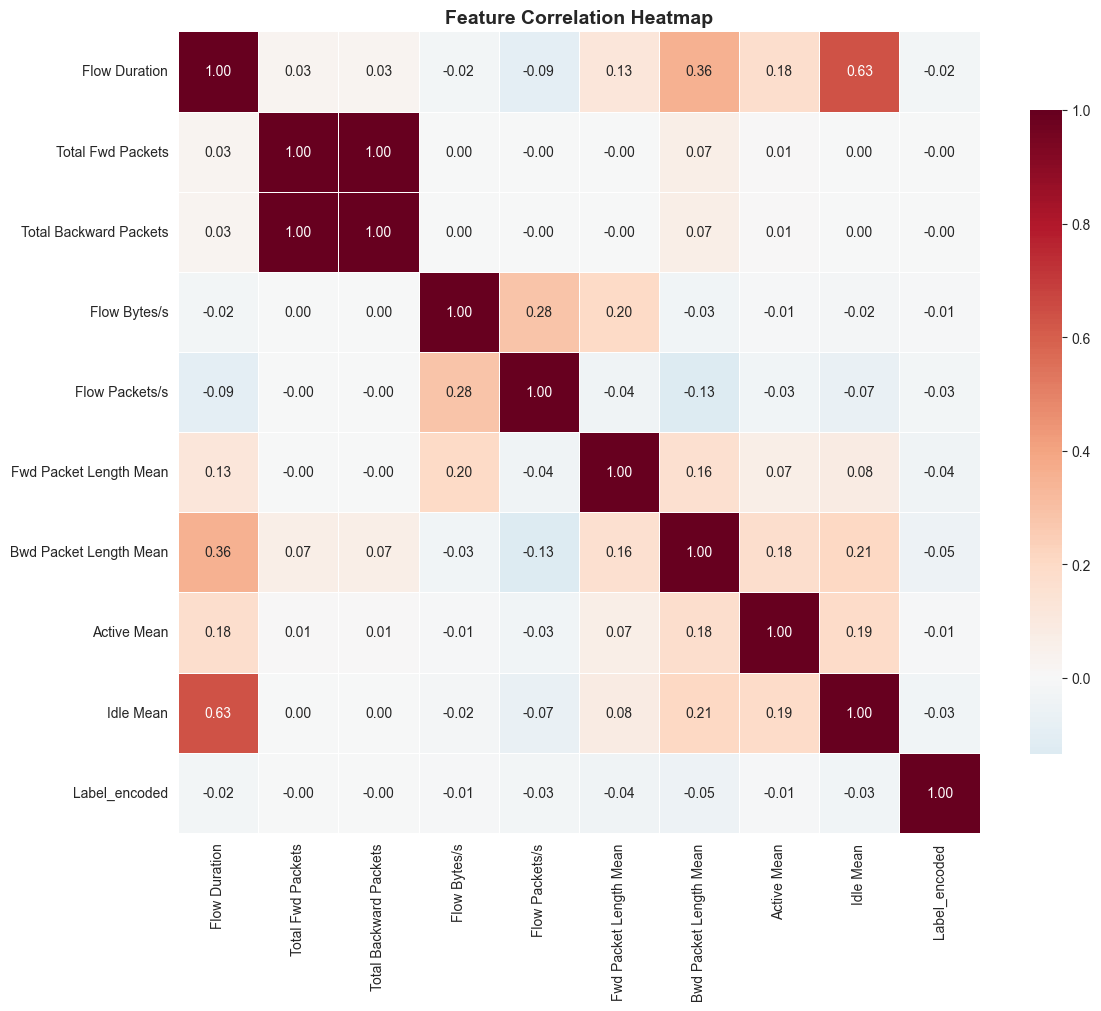

Saved: results/correlation_heatmap.png


In [11]:
# Correlation heatmap for key features
corr_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean',
                 'Bwd Packet Length Mean', 'Active Mean', 'Idle Mean',
                 'Label_encoded']
corr_df = df[corr_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/correlation_heatmap.png')

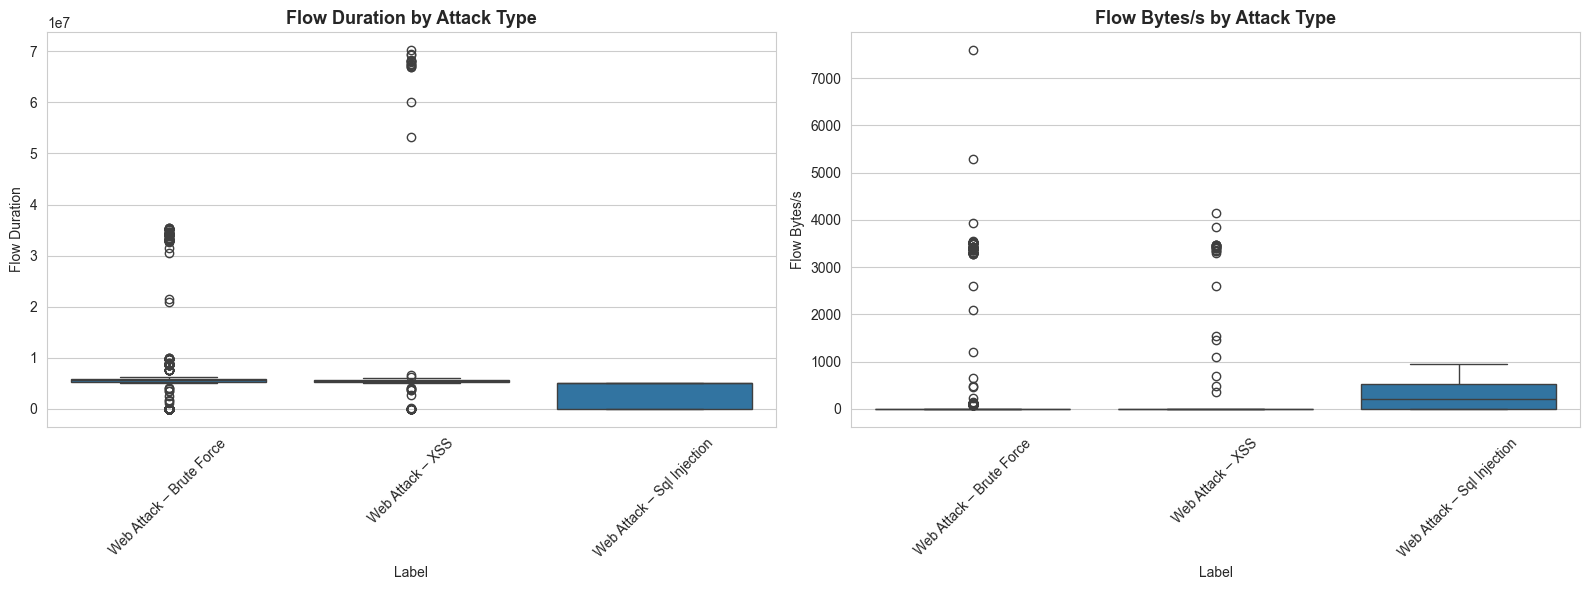

Saved: results/attack_comparison.png


In [12]:
# Compare attack types on key features
attack_types = df[df[LABEL_COL] != 'BENIGN']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: Flow Duration by attack type
sns.boxplot(data=attack_types, x=LABEL_COL, y='Flow Duration', ax=axes[0])
axes[0].set_title('Flow Duration by Attack Type', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Box plot: Flow Bytes/s by attack type
sns.boxplot(data=attack_types, x=LABEL_COL, y='Flow Bytes/s', ax=axes[1])
axes[1].set_title('Flow Bytes/s by Attack Type', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/attack_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/attack_comparison.png')

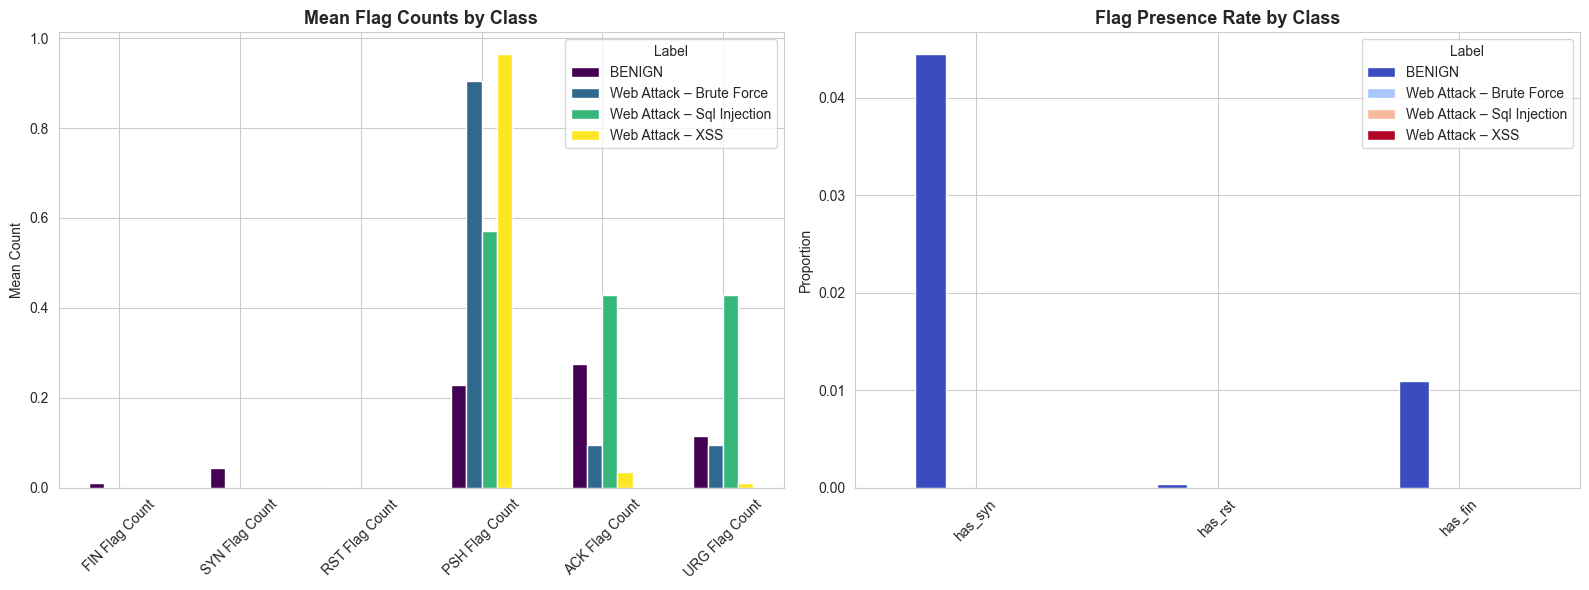

Saved: results/flag_analysis.png


In [13]:
# Flag distribution by class
flag_cols = ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean flags by class
flag_means = df.groupby(LABEL_COL)[flag_cols].mean()
flag_means.T.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Mean Flag Counts by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Mean Count')
axes[0].tick_params(axis='x', rotation=45)

# Flag presence
flag_presence = df.groupby(LABEL_COL)[['has_syn', 'has_rst', 'has_fin']].mean()
flag_presence.T.plot(kind='bar', ax=axes[1], colormap='coolwarm')
axes[1].set_title('Flag Presence Rate by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('results/flag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/flag_analysis.png')

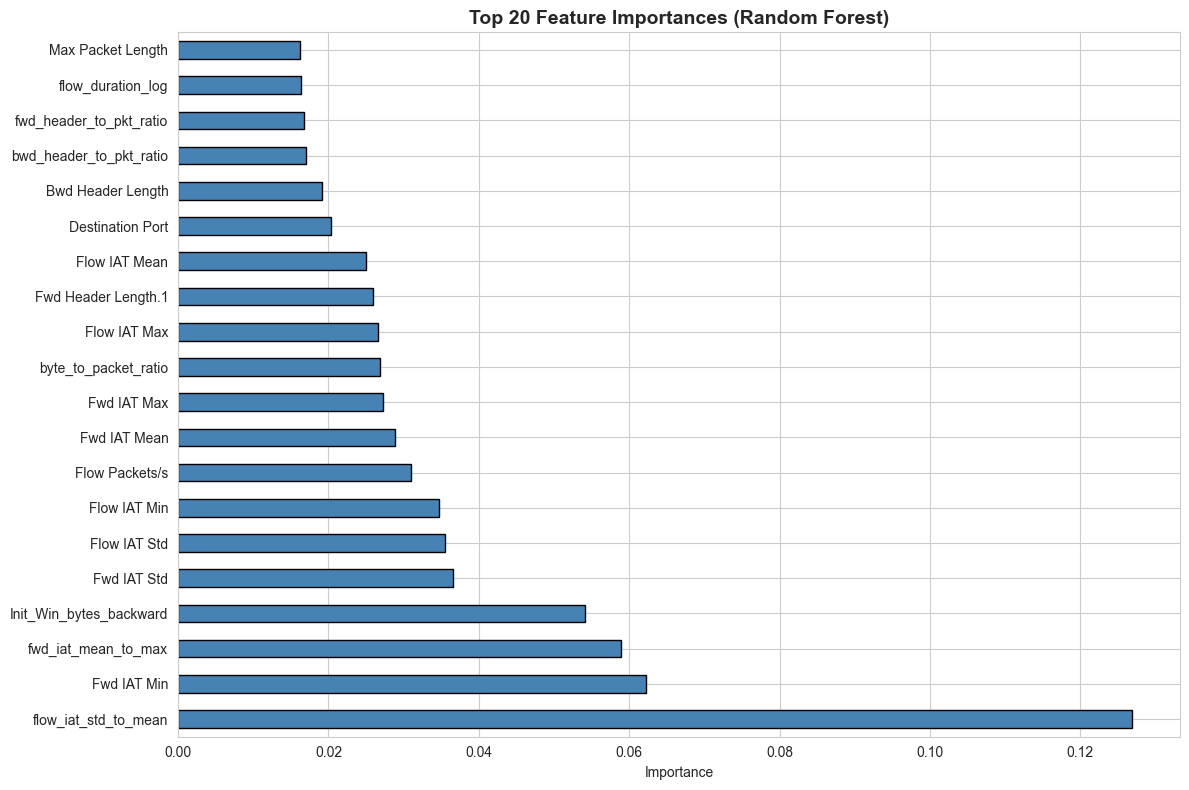

Saved: results/feature_importance.png

Top 10 important features:
flow_iat_std_to_mean       0.126917
Fwd IAT Min                0.062282
fwd_iat_mean_to_max        0.058922
Init_Win_bytes_backward    0.054125
Fwd IAT Std                0.036615
Flow IAT Std               0.035470
Flow IAT Min               0.034684
Flow Packets/s             0.031019
Fwd IAT Mean               0.028908
Fwd IAT Max                0.027267
dtype: float64


In [14]:
# Top features that distinguish BENIGN vs ATTACK
from sklearn.ensemble import RandomForestClassifier

feature_cols = [c for c in df.columns if c not in [LABEL_COL, 'Label_binary', 'Label_encoded', 'Label_multiclass']]
X = df[feature_cols]
y = df['Label_encoded']

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
importances.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/feature_importance.png')
print('\nTop 10 important features:')
print(importances.head(10))

## 6. Feature Reduction
Select the most important features to reduce dimensionality.

In [15]:
# Using the RF importances calculated earlier to select top 20 features
top_features = importances.head(20).index.tolist()
print(f'Selecting Top 20 features: {top_features}')

# Keep metadata/label columns as well
label_cols = [LABEL_COL, 'Label_binary', 'Label_encoded', 'Label_multiclass']
cols_to_keep = top_features + [c for c in label_cols if c in df.columns]

df_reduced = df[cols_to_keep].copy()
print(f'Shape after feature reduction: {df_reduced.shape}')


Selecting Top 20 features: ['flow_iat_std_to_mean', 'Fwd IAT Min', 'fwd_iat_mean_to_max', 'Init_Win_bytes_backward', 'Fwd IAT Std', 'Flow IAT Std', 'Flow IAT Min', 'Flow Packets/s', 'Fwd IAT Mean', 'Fwd IAT Max', 'byte_to_packet_ratio', 'Flow IAT Max', 'Fwd Header Length.1', 'Flow IAT Mean', 'Destination Port', 'Bwd Header Length', 'bwd_header_to_pkt_ratio', 'fwd_header_to_pkt_ratio', 'flow_duration_log', 'Max Packet Length']
Shape after feature reduction: (170365, 24)


## 7. Save Reduced Data

In [16]:
OUTPUT_PATH = 'data/preprocessed/raw/CICDS_reduced.csv'
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

# Final validation
feature_cols = [c for c in df_reduced.columns if c not in [LABEL_COL, 'Label_binary', 'Label_encoded', 'Label_multiclass']]
assert not df_reduced[feature_cols].isna().any().any(), 'NaNs remain in features'
numeric_df_cols = df_reduced.select_dtypes(include=[np.number]).columns
assert not np.isinf(df_reduced[numeric_df_cols]).any().any(), 'Infs remain in features'

df_reduced.to_csv(OUTPUT_PATH, index=False)

print(f'Cleaned data saved to: {OUTPUT_PATH}')
print(f'Final shape: {df_reduced.shape}')
print(f'Columns: {len(df_reduced.columns)}')
print(f'Remaining NaNs: {int(df_reduced.isna().sum().sum())}')
assert not np.isinf(df_reduced[numeric_df_cols]).any().any(), 'Infs remain in features'
print(f'\nLabel distribution (binary):')
print(df_reduced['Label_binary'].value_counts())
print(f'\nLabel distribution (multiclass):')
print(df_reduced[LABEL_COL].value_counts())

Cleaned data saved to: data/preprocessed/raw/CICDS_reduced.csv
Final shape: (170365, 24)
Columns: 24
Remaining NaNs: 0

Label distribution (binary):
Label_binary
BENIGN    168185
ATTACK      2180
Name: count, dtype: int64

Label distribution (multiclass):
Label
BENIGN                        168185
Web Attack – Brute Force        1507
Web Attack – XSS                 652
Web Attack – Sql Injection        21
Name: count, dtype: int64
